# Does Draft Position Predict Career Win Shares in the Modern NBA?

Kian Putnam  
SAL603 Final Project  

## Introduction

The NBA draft is one of the most important mechanisms for team building in professional basketball. Teams invest significant resources into scouting and evaluating prospects with the goal of maximizing long term player value.

This project investigates whether draft position is actually predictive of long term NBA success. Specifically, I analyze whether draft pick number significantly predicts a player’s career Win Shares.

Win Shares is an advanced metric that estimates the number of team wins contributed by a player. It combines offensive and defensive production into one overall value measure. Understanding the strength of this relationship helps evaluate how effective draft positioning truly is as a predictor of player value.


## Research Questions

1. Is draft pick significantly correlated with career Win Shares?
2. How much variation in career Win Shares is explained by draft position?
3. Does draft position remain predictive outside of the lottery?
4. Who have been the biggest steals in recent history based on predicted Win Shares?

## Data Source

All data was scraped directly from Basketball Reference draft pages using the pandas `read_html()` function.

Draft classes from the 2000–2024 NBA seasons were included.

These variables were the main data covered:

- Pick (Draft Position)
- Player
- Career Win Shares (WS)
- Draft Year

All data cleaning and transformations were performed entirely within this Python notebook.

## Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import requests
import time
import seaborn as sns

## Scrape Data

Only run the below code once or Basketball Reference will block other attempts (I found this out the hard way)

In [2]:
all_drafts = []

headers = {"User-Agent": "Mozilla/5.0"}

for year in range(2000, 2024):
    url = f"https://www.basketball-reference.com/draft/NBA_{year}.html"
    
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    
    tables = pd.read_html(response.text, header=1)
    draft = tables[0]
    
    
    draft["DraftYear"] = year
    all_drafts.append(draft)
    
    time.sleep(3)

draft_df = pd.concat(all_drafts, ignore_index=True)

C:\Users\putna\AppData\Local\Temp\ipykernel_114864\3574807484.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text, header=1)
C:\Users\putna\AppData\Local\Temp\ipykernel_114864\3574807484.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text, header=1)
C:\Users\putna\AppData\Local\Temp\ipykernel_114864\3574807484.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text, header=1)
C:\Users\putna\AppData\Local\Temp\ipykernel_114864\3574807484.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and w

In [3]:
draft_df.to_csv("nba_draft_2000_2024.csv", index=False)

In [29]:
draft_df = pd.read_csv("nba_draft_2000_2024.csv")
draft_df.head()

,Rk,Pk,Tm,Player,College,Yrs,G,MP,PTS,TRB,...,FT%,MP.1,PTS.1,TRB.1,AST.1,WS,WS/48,BPM,VORP,DraftYear
0,1,1,NJN,Kenyon Martin,Cincinnati,15,757,23134,9325,5159,...,.629,30.6,12.3,6.8,1.9,48.0,.100,0.1,12.1,2000
1,2,2,VAN,Stromile Swift,LSU,9,547,10804,4582,2535,...,.699,19.8,8.4,4.6,0.5,21.3,.095,-1.6,1.1,2000
2,3,3,LAC,Darius Miles,NaN,7,446,11730,4507,2190,...,.590,26.3,10.1,4.9,1.9,9.5,.039,-1.0,3.0,2000
3,4,4,CHI,Marcus Fizer,Iowa State,6,289,6032,2782,1340,...,.691,20.9,9.6,4.6,1.2,2.7,.022,-3.7,-2.6,2000
4,5,5,ORL,Mike Miller,Florida,17,1032,27812,10973,4376,...,.769,26.9,10.6,4.2,2.6,60.7,.105,0.8,19.8,2000


## Cleaning Data and Exploratory Analysis

In [30]:
draft_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rk         1449 non-null   object
 1   Pk         1449 non-null   object
 2   Tm         1449 non-null   object
 3   Player     1473 non-null   object
 4   College    1153 non-null   object
 5   Yrs        1286 non-null   object
 6   G          1310 non-null   object
 7   MP         1310 non-null   object
 8   PTS        1310 non-null   object
 9   TRB        1310 non-null   object
 10  AST        1310 non-null   object
 11  FG%        1307 non-null   object
 12  3P%        1229 non-null   object
 13  FT%        1283 non-null   object
 14  MP.1       1310 non-null   object
 15  PTS.1      1310 non-null   object
 16  TRB.1      1310 non-null   object
 17  AST.1      1310 non-null   object
 18  WS         1310 non-null   object
 19  WS/48      1309 non-null   object
 20  BPM        1309 non-null   obj

In [31]:
draft_df["Pk"] = pd.to_numeric(draft_df["Pk"], errors="coerce")
draft_df["WS"] = pd.to_numeric(draft_df["WS"], errors="coerce")

draft_df = draft_df.dropna(subset=["Pk", "WS"])

draft_df = draft_df.rename(columns={"Pk": "Pick","WS": "Career_WS"})

#draft_df = draft_df[["Pk", "Player", "WS", "DraftYear"]]

draft_df.head()

,Rk,Pick,Tm,Player,College,Yrs,G,MP,PTS,TRB,...,FT%,MP.1,PTS.1,TRB.1,AST.1,Career_WS,WS/48,BPM,VORP,DraftYear
0,1,1.0,NJN,Kenyon Martin,Cincinnati,15,757,23134,9325,5159,...,.629,30.6,12.3,6.8,1.9,48.0,.100,0.1,12.1,2000
1,2,2.0,VAN,Stromile Swift,LSU,9,547,10804,4582,2535,...,.699,19.8,8.4,4.6,0.5,21.3,.095,-1.6,1.1,2000
2,3,3.0,LAC,Darius Miles,NaN,7,446,11730,4507,2190,...,.590,26.3,10.1,4.9,1.9,9.5,.039,-1.0,3.0,2000
3,4,4.0,CHI,Marcus Fizer,Iowa State,6,289,6032,2782,1340,...,.691,20.9,9.6,4.6,1.2,2.7,.022,-3.7,-2.6,2000
4,5,5.0,ORL,Mike Miller,Florida,17,1032,27812,10973,4376,...,.769,26.9,10.6,4.2,2.6,60.7,.105,0.8,19.8,2000


In [32]:
draft_df.describe()

,Pick,Career_WS,DraftYear
count,1255.000000,1255.000000,1255.000000
mean,27.625498,17.298725,2011.820717
std,16.398204,26.536992,6.912570
min,1.000000,-1.700000,2000.000000
25%,14.000000,0.450000,2006.000000
50%,27.000000,6.300000,2012.000000
75%,41.000000,23.850000,2018.000000
max,60.000000,274.800000,2023.000000


In [33]:
def pick_range(pick):
    if pick <= 5:
        return "Top 5"
    elif pick <= 14:
        return "Lottery"
    elif pick <= 30:
        return "First Round"
    else:
        return "Second Round"

draft_df["Pick_Range"] = draft_df["Pick"].apply(pick_range)

draft_df["Log_Pick"] = np.log(draft_df["Pick"])

In [34]:
range_ws = draft_df.groupby("Pick_Range")["Career_WS"].mean()
print(range_ws)

Pick_Range
First Round     17.229101
Lottery         24.941395
Second Round     8.388561
Top 5           44.069167
Name: Career_WS, dtype: float64


## Visuals

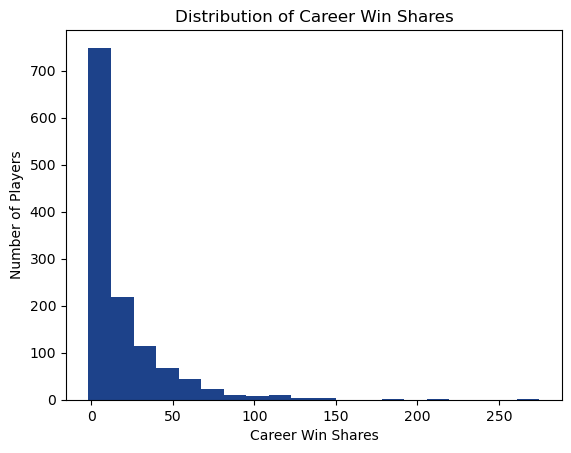

In [39]:
plt.figure()

plt.hist(draft_df["Career_WS"], bins=20, color = "#1D428A")

plt.title("Distribution of Career Win Shares")
plt.xlabel("Career Win Shares")
plt.ylabel("Number of Players")

plt.show()

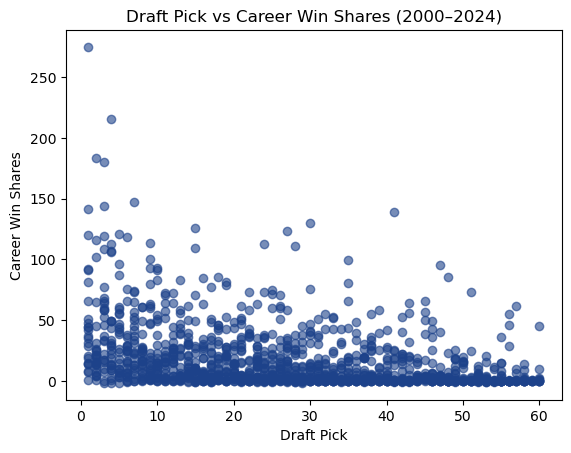

In [40]:
plt.figure()

plt.scatter(draft_df["Pick"], draft_df["Career_WS"], color="#1D428A", alpha=0.6)

plt.xlabel("Draft Pick")
plt.ylabel("Career Win Shares")
plt.title("Draft Pick vs Career Win Shares (2000–2024)")

plt.show()

In [35]:
numeric_cols = ["Pick","Yrs","G","MP","PTS","TRB","AST","FG%","3P%","FT%","MP.1","PTS.1","TRB.1","AST.1",
    "Career_WS","WS/48","BPM","VORP"]

for col in numeric_cols:
    draft_df[col] = pd.to_numeric(draft_df[col], errors="coerce")

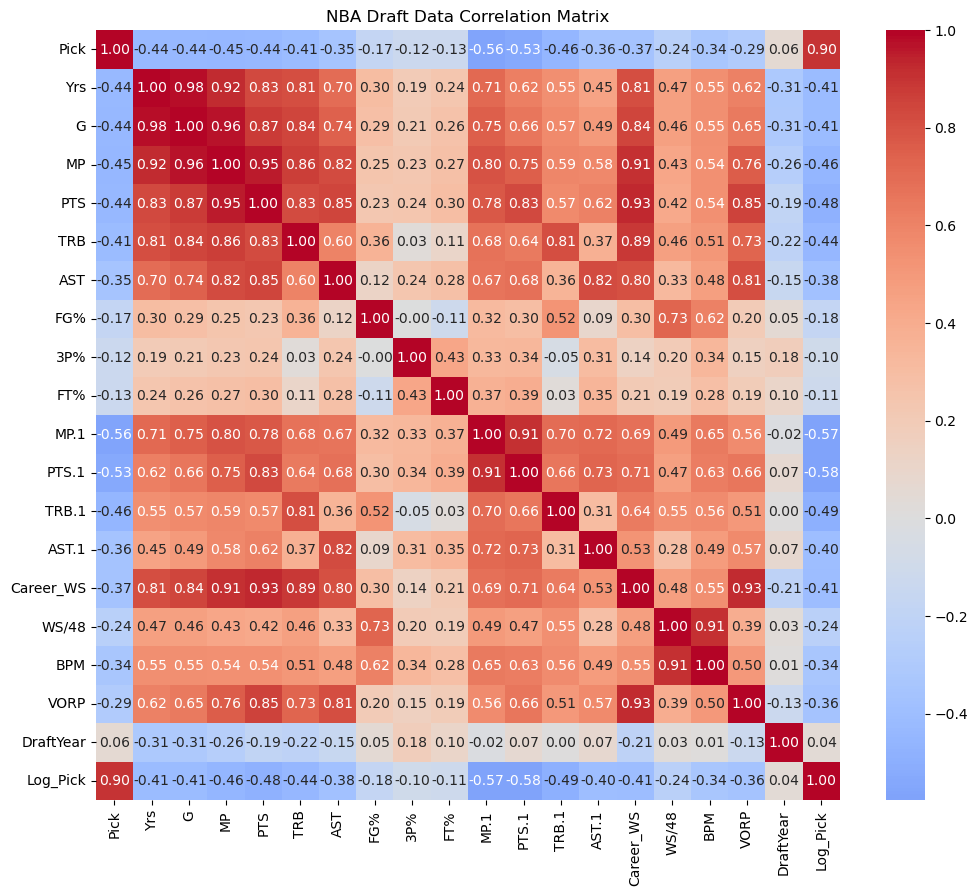

In [36]:
corr_matrix = draft_df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", center=0)

plt.title("NBA Draft Data Correlation Matrix")
plt.show()

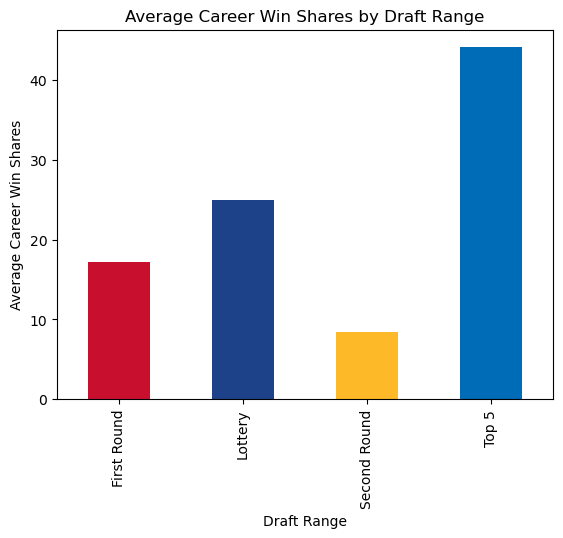

In [37]:
colors = ["#C8102E","#1D428A","#FDB927","#006BB6"]

plt.figure()
range_ws.plot(kind="bar", color=colors)

plt.title("Average Career Win Shares by Draft Range")
plt.ylabel("Average Career Win Shares")
plt.xlabel("Draft Range")

plt.show()

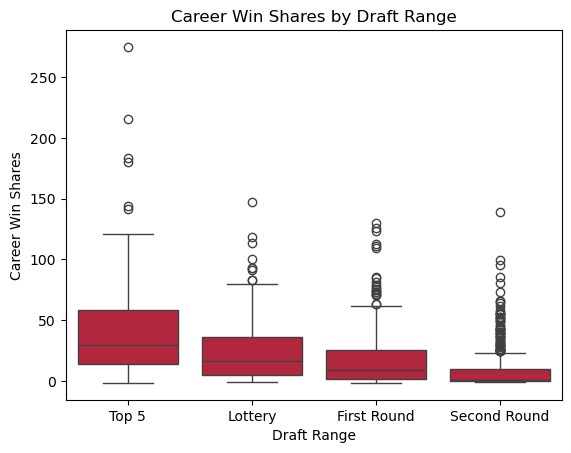

In [38]:
plt.figure()

draft_df["Pick_Range"] = draft_df["Pick"].apply(pick_range)

sns.boxplot(x="Pick_Range", y="Career_WS", data=draft_df, color="#C8102E")

plt.title("Career Win Shares by Draft Range")
plt.xlabel("Draft Range")
plt.ylabel("Career Win Shares")

plt.show()

In [41]:
draft_df.groupby("Pick")["Career_WS"].std()

Pick
1.0     59.304817
2.0     43.012511
3.0     46.164299
4.0     49.358047
5.0     32.388752
6.0     27.633439
7.0     32.980306
8.0     17.541115
9.0     35.490549
10.0    28.952322
11.0    23.810113
12.0    18.637036
13.0    23.369685
14.0    16.946527
15.0    33.964188
16.0    21.158135
17.0    20.165310
18.0    21.474484
19.0    22.831252
20.0    13.203982
21.0    19.826830
22.0    21.469350
23.0    14.714204
24.0    26.736686
25.0    22.823970
26.0    21.860794
27.0    26.485153
28.0    24.150317
29.0    13.972060
30.0    31.400499
31.0    14.597352
32.0    13.986727
33.0    16.583838
34.0    12.508163
35.0    28.912993
36.0    14.738525
37.0     9.985974
38.0    15.474677
39.0    16.663731
40.0    11.460470
41.0    29.816830
42.0    14.746817
43.0    19.164701
44.0     5.989654
45.0    21.827548
46.0    15.980364
47.0    23.989986
48.0    19.307715
49.0     8.535019
50.0     7.741281
51.0    20.022657
52.0     3.781106
53.0     5.863234
54.0     4.066215
55.0     9.203333
56.0 

There is a visible negative relationship between draft pick and career Win Shares. Earlier picks tend to produce higher total Win Shares, though there is substantial variability. There is a slight drop off for each step down, from top 5 picks to the lottery, to the rest of the first round.

## Correlation

In [42]:
correlation = draft_df["Pick"].corr(draft_df["Career_WS"])
print("Correlation between Draft Pick and Career Win Shares:", correlation)

Correlation between Draft Pick and Career Win Shares: -0.3651487445719968


In [43]:
r_squared = correlation ** 2
print("R-squared:", r_squared)

R-squared: 0.13333360566250538


The correlation coefficient between draft pick and career Win Shares is -0.365. The negative sign indicates that lower draft numbers (earlier picks) tend to be associated with higher career Win Shares. Players selected earlier in the draft generally produce more value over the course of their careers. However, the magnitude of the correlation suggests that the relationship is moderate rather than strong. While draft position does appear to matter, it does not fully determine long-term player success.

To further evaluate the strength of the relationship, the coefficient of determination (R²) was calculated. The R² value is 0.133, meaning that draft position explains approximately 13.3% of the variation in career Win Shares. This indicates that while draft pick has some predictive power, the majority of variation in player career performance is driven by other factors such as player development, injuries, team fit, etc.

## Regression

In [44]:
X = draft_df["Pick"]
X = sm.add_constant(X)
y = draft_df["Career_WS"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Career_WS   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     192.8
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           7.12e-41
Time:                        20:22:52   Log-Likelihood:                -5805.0
No. Observations:                1255   AIC:                         1.161e+04
Df Residuals:                    1253   BIC:                         1.162e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.6231      1.367     24.594      0.0

The regression analysis estimates the effect of draft position on career Win Shares.

The coefficient on Pick is -0.5909, indicating that for each one position drop in the draft order, expected career Win Shares decrease by approximately 0.59 wins. Players selected later in the draft tend to contribute fewer wins over the course of their careers.

The regression results also show that draft position is statistically significant. The p-value associated with the Pick coefficient is less than 0.001, meaning the relationship between draft position and career Win Shares is highly unlikely to be due to random chance.

Again however, the R-squared value is 0.133, which indicates that draft position explains only about 13.3% of the variation in career Win Shares. This suggests that while draft position is a meaningful predictor of long-term performance, the majority of variation in player career value is driven by other factors not captured in this model.

Overall, the regression results support the idea that earlier draft picks tend to produce more career value, but they also highlight that draft position alone is far from a complete predictor of NBA success.

## Regression Visualization

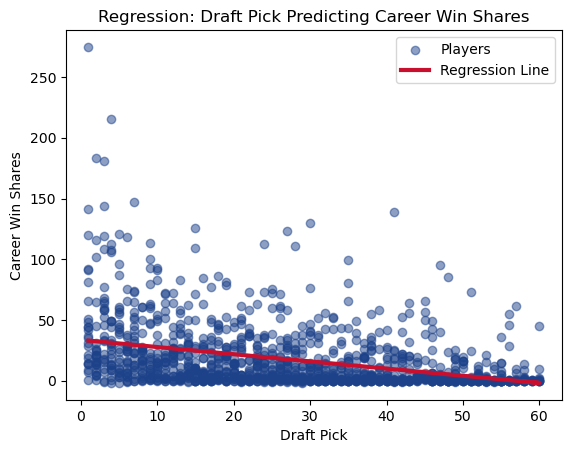

In [45]:
plt.figure()

plt.scatter(
    draft_df["Pick"],
    draft_df["Career_WS"],
    color="#1D428A",
    alpha=0.5,
    label="Players"
)

plt.plot(
    draft_df["Pick"],
    model.predict(X),
    color="#C8102E",
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Draft Pick")
plt.ylabel("Career Win Shares")
plt.title("Regression: Draft Pick Predicting Career Win Shares")

plt.legend()

plt.show()

## Lottery VS Non Lottery

In [46]:
lottery = draft_df[draft_df["Pick"] <= 14]
non_lottery = draft_df[draft_df["Pick"] > 14]

print("Lottery correlation:", lottery["Pick"].corr(lottery["Career_WS"]))
print("Non-lottery correlation:", non_lottery["Pick"].corr(non_lottery["Career_WS"]))

Lottery correlation: -0.2648008096525358
Non-lottery correlation: -0.23324096898094537


To further investigate the relationship between draft position and career success, the dataset was divided into lottery picks (1–14) and non-lottery picks (15 and later).

This allows us to examine whether draft order is more predictive among the highest-valued prospects or whether the relationship remains consistent across the entire draft.

The correlation between draft pick and career Win Shares among lottery selections is -0.265, indicating a modest negative relationship. This suggests that even among the top prospects, players selected earlier tend to generate slightly more career value than those selected later within the lottery.

Among non-lottery selections, the correlation is -0.233. This relationship is slightly weaker but still negative, indicating that draft position continues to have some predictive value even outside the lottery.

Overall, both correlations are weaker than the full-sample correlation, suggesting that while earlier picks generally perform better, the relationship becomes less pronounced when examining smaller portions of the draft. This highlights the increasing uncertainty in projecting long-term player value once teams move beyond the very top of the draft.

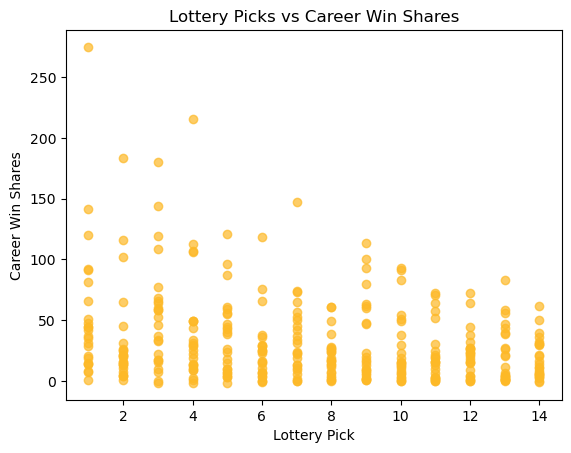

In [47]:
plt.figure()

plt.scatter(lottery["Pick"], lottery["Career_WS"], color="#FDB927", alpha=0.7)

plt.xlabel("Lottery Pick")
plt.ylabel("Career Win Shares")
plt.title("Lottery Picks vs Career Win Shares")

plt.show()

## Draft Steals

In [48]:
draft_df["Predicted_WS"] = model.predict(X)
draft_df["Residual"] = draft_df["Career_WS"] - draft_df["Predicted_WS"]

draft_df.sort_values("Residual", ascending=False).head(20)

,Rk,Pick,Tm,Player,College,Yrs,G,MP,PTS,TRB,...,AST.1,Career_WS,WS/48,BPM,VORP,DraftYear,Pick_Range,Log_Pick,Predicted_WS,Residual
180,1,1.0,CLE,LeBron James,NaN,23,1605,60464,43111,11974,...,7.4,274.8,0.218,8.4,158.4,2003,Top 5,0.000000,33.032138,241.767862
305,4,4.0,NOH,Chris Paul,Wake Forest,21,1370,45836,23058,6006,...,9.2,215.2,0.225,6.5,98.8,2005,Top 5,1.386294,31.259392,183.940608
427,2,2.0,SEA,Kevin Durant,Texas,18,1180,43322,32068,8138,...,4.4,183.2,0.203,6.3,90.8,2007,Top 5,0.693147,32.441223,150.758777
552,3,3.0,OKC,James Harden,Arizona State,17,1204,41868,28977,6731,...,7.3,180.5,0.207,6.2,86.9,2009,Top 5,1.098612,31.850308,148.649692
902,41,41.0,DEN,Nikola JokiÄ,NaN,11,791,25239,17528,8721,...,7.4,139.0,0.264,10.6,79.9,2014,Second Round,3.713572,9.395528,129.604472
556,7,7.0,GSW,Stephen Curry,Davidson,17,1065,36197,26447,4957,...,6.3,147.0,0.195,6.4,77.0,2009,Lottery,1.945910,29.486647,117.513353
703,30,30.0,CHI,Jimmy Butler,Marquette,15,907,29972,16658,4858,...,4.4,129.6,0.208,5.0,52.8,2011,First Round,3.401197,15.895596,113.704404
62,3,3.0,ATL,Pau Gasol,NaN,18,1226,41001,20894,11305,...,3.2,144.1,0.169,3.6,57.5,2001,Top 5,1.098612,31.850308,112.249692
240,1,1.0,ORL,Dwight Howard,NaN,18,1242,39457,19485,14627,...,1.3,141.7,0.172,1.9,39.0,2004,Top 5,0.000000,33.032138,108.667862
824,27,27.0,DEN,Rudy Gobert,NaN,13,888,27287,11098,10378,...,1.4,123.1,0.217,3.1,35.4,2013,First Round,3.295837,17.668341,105.431659


C:\Users\putna\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 135 (\x87) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


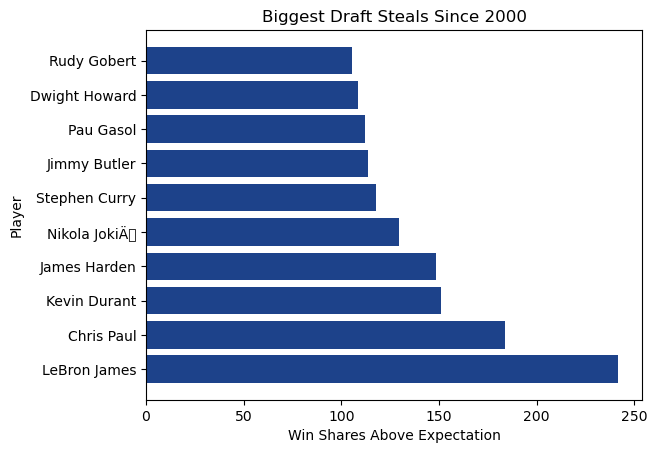

In [51]:
steals = draft_df.sort_values("Residual", ascending=False).head(10)

plt.figure()

plt.barh(steals["Player"], steals["Residual"], color = "#1D428A")

plt.title("Biggest Draft Steals Since 2000")
plt.xlabel("Win Shares Above Expectation")
plt.ylabel("Player")

plt.show()

Players with the highest positive residuals significantly outperformed what their draft position predicted. These players represent the biggest draft steals in the dataset.

## Conclusions

This analysis examined whether NBA draft position is predictive of long-term player success, measured by career Win Shares. The results show a statistically significant negative relationship between draft position and career Win Shares. Earlier draft picks tend to produce higher overall player value, while players selected later in the draft generally accumulate fewer career Win Shares.

However, the strength of this relationship is moderate rather than strong. The correlation between draft position and career Win Shares was approximately -0.37, indicating a meaningful but not overwhelming association. The regression analysis produced an R-squared value of about 0.13, meaning that draft position explains only about 13% of the variation in career Win Shares. This suggests that while draft order does provide useful information about expected player value, the majority of career outcomes are influenced by other factors such as player development, injuries, team context, and opportunity.

When examining draft position within subsets of the draft, the relationship becomes slightly weaker. The correlation among lottery picks was approximately -0.26, while the non-lottery picks had a correlation of about -0.23. This indicates that although earlier selections within these groups still tend to perform better, outcomes become more unpredictable as teams move further down the draft board.

Additionally, the analysis of regression residuals revealed several players who significantly exceeded or fell short of expectations based on their draft position. These cases highlight the presence of both draft steals and underperforming high picks, reinforcing the idea that evaluating basketball talent involves substantial uncertainty.

Overall, the results suggest that draft position does matter and is statistically related to long-term player performance. However, it is far from a perfect predictor of success. While teams may improve their odds of selecting productive players with earlier picks, the NBA draft remains an inherently uncertain process where unexpected outcomes are common.